# 🛡️ SecureMind AI — How to Use Exported Models

This notebook shows how to load and use the pre-trained SecureMind AI models for inference.

**Available Models:**
- **Phishing Email Classifier** — Random Forest + TF-IDF (`Phishing/`)
- **Network Intrusion Detection** — Random Forest  (`CICIDS2017/`)

> All paths are relative to the `models/` directory where this notebook lives.


---
## Part 1 — Phishing Email Classifier


### 1. Import Required Libraries

In [10]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported')


✅ Libraries imported


### 2. Load Exported Phishing Artifacts

In [11]:
# Paths are relative to this notebook (models/)
phishing_model     = joblib.load('Phishing/best_phishing_model.pkl')
phishing_vectorizer = joblib.load('Phishing/tfidf_vectorizer.pkl')
phishing_labels    = joblib.load('Phishing/label_map.pkl')

print(f'✅ Model loaded      : {type(phishing_model).__name__}')
print(f'✅ Vectorizer loaded : vocab size = {len(phishing_vectorizer.get_feature_names_out())}')
print(f'✅ Label map         : {phishing_labels}')


✅ Model loaded      : RandomForestClassifier
✅ Vectorizer loaded : vocab size = 5000
✅ Label map         : {0: 'Legitimate', 1: 'Phishing'}


### 3. Preprocess Input Text

In [12]:
def preprocess_and_vectorize(texts, vectorizer):
    """Convert raw email text(s) to TF-IDF feature matrix."""
    if isinstance(texts, str):
        texts = [texts]
    texts = [str(t) for t in texts]
    return vectorizer.transform(texts)

print('✅ Helper function defined')


✅ Helper function defined


### 4. Single Email Prediction

In [13]:
def predict_email(text, model, vectorizer, label_map):
    """Predict whether a single email is phishing or legitimate."""
    X = preprocess_and_vectorize(text, vectorizer)
    pred = model.predict(X)[0]
    proba = model.predict_proba(X)[0]
    label = label_map[pred]
    confidence = proba[pred] * 100
    print(f'  Prediction  : {label}')
    print(f'  Confidence  : {confidence:.2f}%')
    print(f'  Probabilities: Legitimate={proba[0]*100:.2f}%  Phishing={proba[1]*100:.2f}%')
    return label, proba

In [14]:
print('=' * 50)
print('📧 Example 1 — Legitimate Email')
print('=' * 50)
legitimate_email = """
Hi Team,
Please find attached the Q3 financial report for your review.
The meeting is scheduled for Thursday at 10am in Conference Room B.
Best regards,
Sarah
"""
predict_email(legitimate_email, phishing_model, phishing_vectorizer, phishing_labels)

print('=' * 50)
print('🎣 Example 2 — Phishing Email')
print('=' * 50)
phishing_email = """
URGENT: Your account has been compromised!
Click here immediately to verify your identity and avoid suspension:
http://secure-login-verify.xyz/update?user=you
Enter your username, password, and credit card details NOW.
"""
predict_email(phishing_email, phishing_model, phishing_vectorizer, phishing_labels)


📧 Example 1 — Legitimate Email
  Prediction  : Legitimate
  Confidence  : 60.02%
  Probabilities: Legitimate=60.02%  Phishing=39.98%
🎣 Example 2 — Phishing Email
  Prediction  : Phishing
  Confidence  : 72.20%
  Probabilities: Legitimate=27.80%  Phishing=72.20%


('Phishing', array([0.27803805, 0.72196195]))

### 5. Batch Email Prediction

In [15]:
batch_emails = [
    "Hi, please review the attached document for tomorrow's meeting.",
    "Congratulations! You've won $1,000,000. Click here to claim your prize now!",
    "Your invoice #4821 is attached. Payment is due by end of month.",
    "ALERT: Unusual login detected. Verify account immediately at http://phish-site.ru/login",
    "Team lunch is confirmed for Friday at noon in the main cafeteria.",
    "Your password expires in 24 hours. Update it here: http://fake-bank-update.com",
]

X_batch = preprocess_and_vectorize(batch_emails, phishing_vectorizer)
preds = phishing_model.predict(X_batch)
probas = phishing_model.predict_proba(X_batch)

results_df = pd.DataFrame({
    'Email (truncated)': [e[:60] + '...' for e in batch_emails],
    'Prediction': [phishing_labels[p] for p in preds],
    'P(Legitimate)': [f'{p[0]*100:.1f}%' for p in probas],
    'P(Phishing)':   [f'{p[1]*100:.1f}%' for p in probas],
})

results_df.style.applymap(
    lambda v: 'background-color: #ffcccc' if v == 'Phishing' else 'background-color: #ccffcc',
    subset=['Prediction']
)


,Email (truncated),Prediction,P(Legitimate),P(Phishing)
0,"Hi, please review the attached document for tomorrow's meeti...",Legitimate,55.2%,44.8%
1,"Congratulations! You've won $1,000,000. Click here to claim ...",Phishing,32.3%,67.7%
2,Your invoice #4821 is attached. Payment is due by end of mon...,Phishing,49.0%,51.0%
3,ALERT: Unusual login detected. Verify account immediately at...,Phishing,29.1%,70.9%
4,Team lunch is confirmed for Friday at noon in the main cafet...,Phishing,45.0%,55.0%
5,Your password expires in 24 hours. Update it here: http://fa...,Phishing,34.3%,65.7%


### 6. Visualize Prediction Confidence

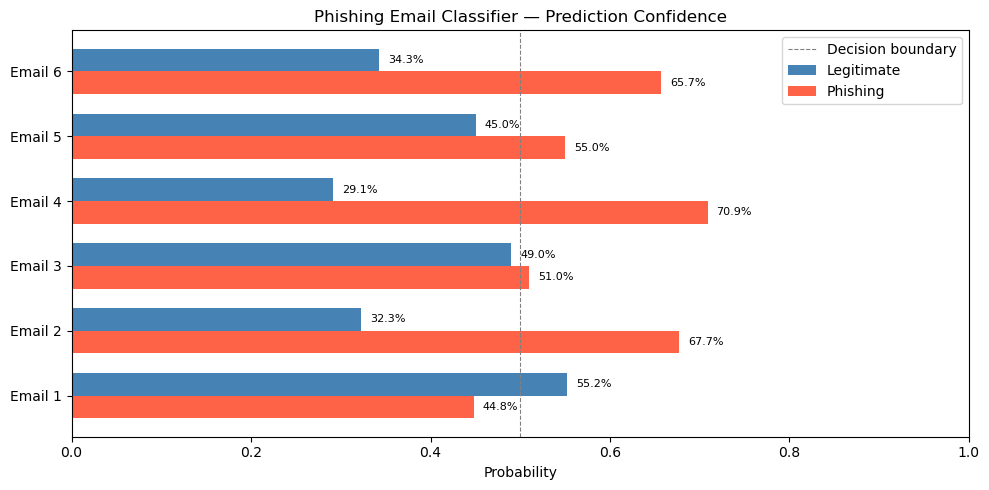

In [16]:
labels_short = [f'Email {i+1}' for i in range(len(batch_emails))]
p_legit   = probas[:, 0]
p_phish   = probas[:, 1]

x = np.arange(len(labels_short))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.barh(x + width/2, p_legit, width, label='Legitimate', color='steelblue')
bars2 = ax.barh(x - width/2, p_phish, width, label='Phishing',   color='tomato')

ax.set_xlabel('Probability')
ax.set_title('Phishing Email Classifier — Prediction Confidence')
ax.set_yticks(x)
ax.set_yticklabels(labels_short)
ax.set_xlim(0, 1)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Decision boundary')
ax.legend()

# Annotate bars
for bar in bars1:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width()*100:.1f}%', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width()*100:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()


---
## Part 2 — Network Intrusion Detection (CICIDS2017)


### 7. Load CICIDS2017 Artifacts

In [17]:
ids_model  = joblib.load('CICIDS2017/cicids2017_best_model_random_forest.joblib')
ids_scaler = joblib.load('CICIDS2017/cicids2017_scaler.joblib')
ids_labels = joblib.load('CICIDS2017/cicids2017_label_map.joblib')

print(f'✅ IDS Model loaded  : {type(ids_model).__name__}')
print(f'✅ Scaler loaded     : {type(ids_scaler).__name__}')
print(f'✅ Label map         :')
for k, v in ids_labels.items():
    print(f'   {k} → {v}')
print(f'\n✅ Expected features : {ids_model.n_features_in_}')


✅ IDS Model loaded  : RandomForestClassifier
✅ Scaler loaded     : StandardScaler
✅ Label map         :
   0 → Bots
   1 → Brute Force
   2 → DDoS
   3 → DoS
   4 → Normal Traffic
   5 → Port Scanning
   6 → Web Attack – Brute Force
   7 → Web Attack – SQL Injection
   8 → Web Attack – XSS

✅ Expected features : 47


### 8. Single Network Flow Prediction

A network flow sample must supply the same numeric features the model was trained on.  
The example below creates a random benign-like flow — replace the values with real features from your data.


In [18]:
def predict_network_flow(features_array, model, scaler, label_map):
    """
    Predict the traffic class for one or more network flow samples.

    Parameters
    ----------
    features_array : array-like, shape (n_samples, n_features)
    model          : trained sklearn classifier
    scaler         : fitted StandardScaler
    label_map      : dict mapping integer class index → string label

    Returns
    -------
    predictions (list of str), probabilities (ndarray)
    """
    X = np.array(features_array)
    if X.ndim == 1:
        X = X.reshape(1, -1)
    X_scaled = scaler.transform(X)
    preds  = model.predict(X_scaled)
    probas = model.predict_proba(X_scaled)
    labels = [label_map[p] for p in preds]
    return labels, probas

# --- Example: single flow (all zeros as a placeholder — replace with real values) ---
n_features = ids_model.n_features_in_
sample_flow = np.zeros(n_features)   # ← replace with actual feature values

pred_labels, pred_probas = predict_network_flow(sample_flow, ids_model, ids_scaler, ids_labels)
print(f'Predicted class  : {pred_labels[0]}')
print(f'Top-3 confidence :')
top3_idx = np.argsort(pred_probas[0])[::-1][:3]
for idx in top3_idx:
    print(f'  {ids_labels[idx]:30s} {pred_probas[0][idx]*100:.2f}%')


Predicted class  : Normal Traffic
Top-3 confidence :
  Normal Traffic                 94.39%
  DoS                            4.53%
  Brute Force                    1.00%


### 9. Batch Prediction from Test CSV

In [20]:
import os

TEST_CSV = '../data_output/cicids2017_test.csv'

if os.path.exists(TEST_CSV):
    test_df = pd.read_csv(TEST_CSV)
    print(f'✅ Test set loaded: {test_df.shape}')

    # Drop label column
    feature_cols = [c for c in test_df.columns if c.strip().lower() != 'label']

    # Prefer the exact feature names the scaler was fitted on
    if hasattr(ids_scaler, 'feature_names_in_'):
        feature_cols = list(ids_scaler.feature_names_in_)
        print(f'   Using {len(feature_cols)} named features from scaler')
    else:
        # Fallback: take the first n_features_in_ columns
        n = ids_scaler.n_features_in_
        feature_cols = feature_cols[:n]
        print(f'   Using first {n} feature columns (scaler has no feature_names_in_)')

    X_test_ids = test_df[feature_cols].values
    print(f'   Feature matrix shape: {X_test_ids.shape}')

    batch_labels, batch_probas = predict_network_flow(X_test_ids, ids_model, ids_scaler, ids_labels)

    test_df['Predicted'] = batch_labels
    print(f'\nPrediction distribution:')
    print(test_df['Predicted'].value_counts())

    # Show sample
    test_df[['Predicted'] + feature_cols[:4]].head(10)
else:
    print(f'⚠️  Test CSV not found at {TEST_CSV}')
    print('   Run the CICIDS2017 model-training notebook first to generate it.')


✅ Test set loaded: (378113, 48)
   Using 47 named features from scaler
   Feature matrix shape: (378113, 47)

Prediction distribution:
Predicted
Normal Traffic              314377
DoS                          28985
DDoS                         19198
Port Scanning                13727
Brute Force                   1371
Web Attack – Brute Force       299
Bots                           145
Web Attack – XSS                11
Name: count, dtype: int64


---
## Summary

| Model | Artifact files | Input type | Output |
|---|---|---|---|
| Phishing Email Classifier | `Phishing/best_phishing_model.pkl` + `tfidf_vectorizer.pkl` + `label_map.pkl` | Raw email text | `Legitimate` / `Phishing` |
| Network Intrusion Detection | `CICIDS2017/cicids2017_best_model_random_forest.joblib` + `cicids2017_scaler.joblib` + `cicids2017_label_map.joblib` | Numeric flow features | Attack class label |

**Usage pattern (both models):**
1. Load artifacts with `joblib.load()`
2. Preprocess input (vectorize text **or** scale numeric features)
3. Call `model.predict()` for class labels
4. Call `model.predict_proba()` for confidence scores
